# Raster Data and `rioxarray`

We have used the analogy that `rioxarray` is to `xarray` what `geopandas` is to `pandas`. To be more precise, the classic way of interfacing with raster data within a Python framework has been [a package called `rasterio`](https://rasterio.readthedocs.io/en/stable/) (short for raster input-output). `rasterio` is powerful, but does not necessarily sit intuitively alongside the rest of the modern geospatial stack. For instance, to analyse data using `rasterio`, you have to read data into standard `numpy` arrays, whilst keeping track of e.g. pixel coordinates, CRS, and band names in seperate variables. Basic tasks require a lot of 'boilerplate code': reptitive, non-analytical lines of code just to keep track of metadata.

`rioxarray` moves this functionality to `xarray` (and indeed, much of the functionality is still running `rasterio` in the background), providing a high-level interface for working with raster data that aligns with our prior knowledge about how to use `xarray` and `pandas`. Whilst `rioxarray` does have a seperate module (i.e. `import rioxarray as rxr` alongside `import xarray as xr`), there are no special datatype (e.g. a "`RioDataSet"`): instead, most work is done through an "`xarray` accessor", which allows custom functions to be accessed through a custom namespace of the `DataSet` variable - e.g. `ds.rio.custom_rioxarray_function()`. 

There are [many `xarray` accessors](https://docs.xarray.dev/en/latest/user-guide/ecosystem.html) that aim to extend `xarray` with many specialist functions. As well as `rioxarray`, in this section we will also make use of [the `xarray-spatial` package](https://xarray-spatial.readthedocs.io), to provide fast additional capability for a variety of topographic analysis.

To ensure `rioxarray` and `xarray-spatial` are installed, enter your `conda` environment and run the command `conda install -c conda-forge rioxarray xarray-spatial`.

In [2]:
import xarray as xr
import rioxarray as rxr
import xrspatial

import matplotlib.pyplot as plt

## Single-band raster

### How `rioxarray` extends `xarray`

First, we will examine a raster with only a single band. Download the following data to the same directory as your notebook:

 - [Bristol Copernicus GLO-30 digital elevation model](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/04/bristol_copdem30.tif)

This dataset, the [Copernicus GLO-30 DEM](https://portal.opentopography.org/raster?opentopoID=OTSDEM.032021.4326.3), is a 30-metre-resolution digital surface model (i.e. a topographic model that includes surface features such as buildings and trees). It exists as a GeoTiff file (`.tif`), which is a [standard data format](https://en.wikipedia.org/wiki/GeoTIFF) for geospatial raster data. It modifies the common [TIFF file format](https://en.wikipedia.org/wiki/TIFF) (which, if you are a photographer, you might have encountered for storing photos in a 'lossless' format) to allow for metadata containing information about coordinate reference systems, allowing us to know exactly where the pixels in the image are located in space.

We can open our GeoTiff using the custom `rxr.open_rasterio()` function:

In [4]:
dem = rxr.open_rasterio("bristol_copdem30.tif")

dem

<xarray.DataArray (band: 1, y: 541, x: 793)> Size: 2MB
[429013 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 4kB 51.53 51.53 51.53 51.53 ... 51.38 51.38 51.38
  * x            (x) float64 6kB -2.76 -2.76 -2.759 ... -2.431 -2.43 -2.43
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      data

Note that the data type is still an `xarray` `DataArray` (not a seperate data type, as a `GeoDataFrame` was to a `DataFrame`). 

The dimensions contain `x` and `y` coordinates, as expected. There is a `band` dimension of length `1`. If the `.tif` contained more than one band, then this would be longer. As it is only one band, we can remove it using the `.squeeze()` function - this is always useful to do as some functions can be confused when receiving a "3-D" dataframe that is in fact only 3-D. Take a look at how the `band` coordinate disappears from being a dimension:

In [9]:
dem = dem.squeeze()  # Remove the band dimension if it exists

dem

<xarray.DataArray (y: 541, x: 793)> Size: 2MB
[429013 values with dtype=float32]
Coordinates:
  * y            (y) float64 4kB 51.53 51.53 51.53 51.53 ... 51.38 51.38 51.38
  * x            (x) float64 6kB -2.76 -2.76 -2.759 ... -2.431 -2.43 -2.43
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      data

Additionally, there is a `spatial_ref` coordinate. This is a special `rioxarray` coordinate that stores information about the coordinate reference system. If we visualise it using `dem.spatial_ref`, it might not look very impressive (apparently, it seems to just be a `numpy` array containing the number `0`). However, if you click the drop-down "Attributes" bar, you will see the value of the `spatial_ref` data:

In [10]:
dem.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 8B
array(0)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    crs_wkt:                      GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984
    grid_mapping_name:            latitude_longitude
    spatial_ref:                  GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    GeoTransform:                 -2.7602083333333334 0.00041666666666666675 ...

These attributes contain everything needed to reconstruct the coordinate reference system, including the EPSG, WKT string, ellipsoid information, datums, and transform.

As a result, we can take advantage of special `rioxarray` accessor functions (via `.rio`) to call upon geospatial attributes, such as the CRS, bounds, and resolution:

In [16]:
print("CRS of DEM DataArray:", dem.rio.crs)
print("Bounds of DEM DataArray:", dem.rio.bounds())
print("Resolution of DEM DataArray:", dem.rio.resolution())

CRS of DEM DataArray: EPSG:4326
Bounds of DEM DataArray: (-2.7602083333333334, 51.37986111111111, -2.429791666666667, 51.53013888888889)
Resolution of DEM DataArray: (0.00041666666666666675, -0.0002777777777777751)


### Plotting and manipulating `DataArrays`

Anyway, now that we've explored this, let's visualise the data using `.plot.imshow()`:

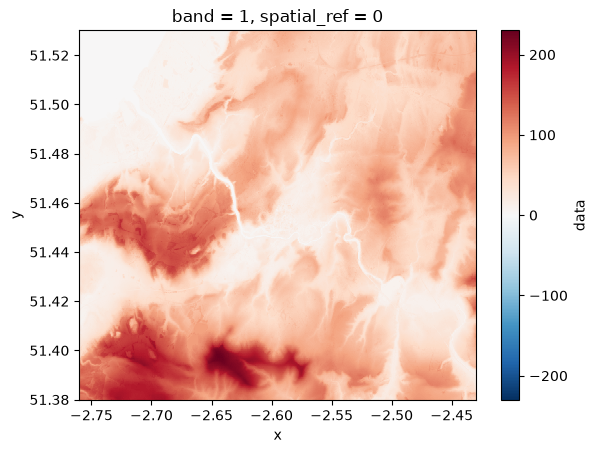

In [11]:
dem.plot.imshow()

Note the slightly unusual colour scale here: rather than the usual `viridis` default, `xarray` has selected a divergent red-blue scale going from over 200 to under -200. This is the default `xarray` plotting behaviour when it detects values on both sides of zero: it will produce a divergent red-blue colourmap centred on zero.

Our DEM has values beneath zero: even though the data comes geoid-corrected (to the EGM2008) geoid as standard, there are still a few pixels - be they legitimate or data errors - that are beneath zero:

In [33]:
print("Minimum value of DEM DataArray:", dem.min().item())
print("Maximum value of DEM DataArray:", dem.max().item())

n_pixels_below_zero = (dem < 0).sum().item()
print("Number of pixels with values below 0 metres:", n_pixels_below_zero)

Minimum value of DEM DataArray: -7.117240905761719
Maximum value of DEM DataArray: 230.1975555419922
Number of pixels with values below 0 metres: 11


Therefore, for might want to pay slightly more attention to the details when plotting this:

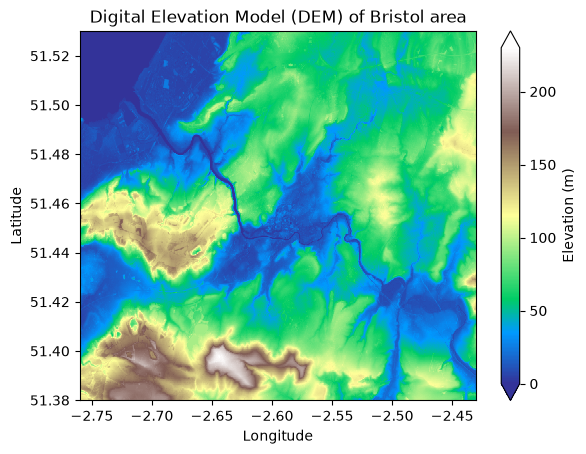

In [75]:
fig, ax = plt.subplots()

dem.plot.imshow(ax=ax, cmap="terrain", vmin=0, vmax=230, cbar_kwargs={"label": "Elevation (m)"})

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("Digital Elevation Model (DEM) of Bristol area")

plt.show()

As usual, you can do all sorts of typical manipulations with this dataset in the same way you could do for a typical `xarray` or `pandas` dataset. For instance, here is a simple example of converting between units:

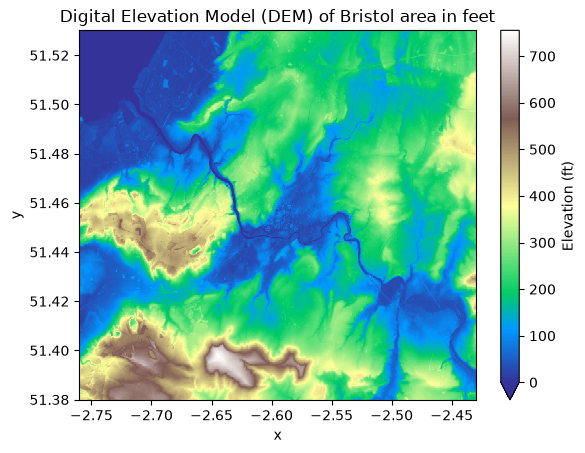

In [48]:
# convert from metres to feet
dem_feet = dem * 3.28084

# plot the DEM in feet
dem_feet.plot.imshow(vmin=0, cmap="terrain", cbar_kwargs={"label": "Elevation (ft)"})

plt.title("Digital Elevation Model (DEM) of Bristol area in feet")

plt.show()

### Reprojecting

You might have noticed above that our data has once again come in units of degrees latitude/longitude (EPSG:4326). Luckily, like with geopandas, it is possible to convert data from one format to another. It would be nice to be able to use a CRS with units of metres.

Whilst we could just choose the British National Grid (see last week's content), satellite data is very often delivered in [Universal Transverse Mercator (UTM) projections](https://en.wikipedia.org/wiki/Universal_Transverse_Mercator_coordinate_system). These set of projections divide the earth into 60 narrow strips of 6˚ of longitude: within each zone, each UTM projection aims to approximate, as closely as possible, square pixels with fixed linear cell dimensions (e.g. 30 m x 30 m) to simplify raster operations.

This is so common that `rioxarray` even has a function to find the most appropriate UTM for the dataset:

In [36]:
dem.rio.estimate_utm_crs()

CRS.from_epsg(32630)

This suggests that our dataset belongs in EPSG:32360, which is UTM Zone 30N. [Indeed, looking at the projection covered area on the epsg.io website](https://epsg.io/32630) suggests this is exactly appropriate: UTM Zone 30N covers -6˚E to 0˚E.

We can reproject to this desired format using the `.rio.reproject()` function:

In [ ]:
# reproject to EPSG:32630, resolution of 30 metres, and resample using bilinear interpolation
dem_reprojected = dem.rio.reproject("EPSG:32630", resolution=30, resampling="bilinear")

Note that we provide a couple additional arguments: one that says we want our resolution to be `30` map units (i.e. metres), and one that says how we want to resample our data. Resampling refers to the process of interpolating new pixel values when we shift and rotate the grids. Bilinear interpolation does this by taking a distance-weighted average of the 4 nearest input pixel centres to the 'new' pixel centroid.

Now we can plot in this new projection:

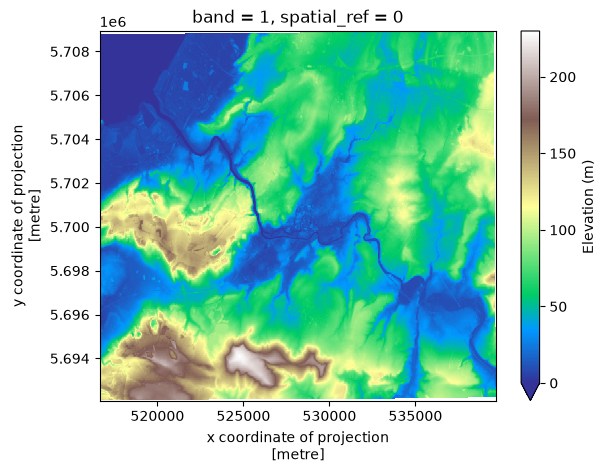

In [46]:
dem_reprojected.plot.imshow(vmin=0, cmap="terrain", cbar_kwargs={"label": "Elevation (m)"})

Note that there a slight empty gaps visible at the edges of the new DEM. This is because the new UTM projection is rotated slightly compared to the old EPSG:4326 projection, introducing 'gaps' in the new grid that the old extent doesn't cover.

Anyway, now that we have data in units of metres and a unit resolution of `30`, we also now know that each of our pixels occupies an area of (30 x 30 =) 900 m<sup>2</sup>. With this fact, we could begin answer questions about the area of some selected regions. for instance, what is the total area of the grid?

In [60]:
x_length,y_length = dem_reprojected.shape  # length of x and y dimensions in pixels

dem_total_area = x_length * y_length * 30 * 30  # area in square metres

print("Total area of DEM DataArray:", dem_total_area, "square metres")

dem_total_area_km2 = dem_total_area / 1e6  # convert to square kilometres

print("Total area of DEM DataArray:", dem_total_area_km2, "square kilometres")

Total area of DEM DataArray: 388960200 square metres
Total area of DEM DataArray: 388.9602 square kilometres


And how much of our region is above 100 m in elevation?

Total area of DEM DataArray above 100 metres: 68927400 square metres
Total area of DEM DataArray above 100 metres: 68.9274 square kilometres
Total fraction of the DEM DataArray above 100 metres: 0.17720939057517968


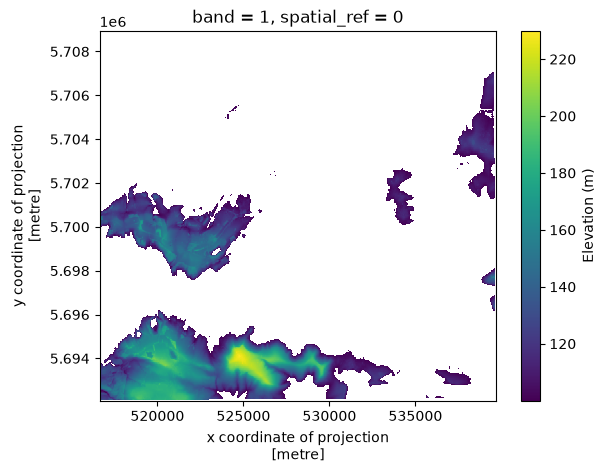

In [62]:
# get area above 100 metres

dem_above_100m = dem_reprojected.where(dem_reprojected >= 100)

dem_above_100m.plot.imshow(cbar_kwargs={"label": "Elevation (m)"})

dem_above_100m_area = (dem_above_100m.count() * 30 * 30).item()  # area in square metres

print("Total area of DEM DataArray above 100 metres:", dem_above_100m_area, "square metres")

print("Total area of DEM DataArray above 100 metres:", dem_above_100m_area / 1e6, "square kilometres")

print("Total fraction of the DEM DataArray above 100 metres:", dem_above_100m_area / dem_total_area)


### Clipping

As with `geopandas`, we can also clip our data to new extents. You can actually provide shapely geometries to clip to custom extents (we will do this later in the course), but for now a handy tool (analogous to the shapely `box` tool) is `.rio.clip_box()`, where we can simply provide a bounding box. Let's zoom in on Bristol:

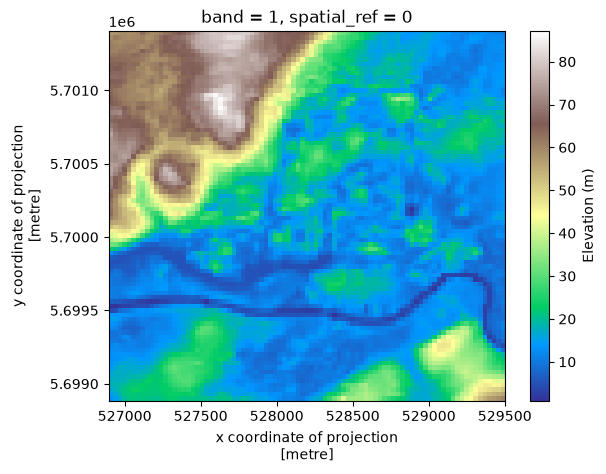

In [115]:
# Bounds of central bristol area in EPSG:32630 coordinates (x_min, y_min, x_max, y_max)
bristol_zoom_bounds = 526900, 5698900, 529500, 5701400

# Clip the DEM to the central Bristol area using the defined bounds
dem_reproj_clip = dem_reprojected.rio.clip_box(*bristol_zoom_bounds)

# Plot the clipped DEM
dem_reproj_clip.plot.imshow(cmap='terrain', cbar_kwargs={"label": "Elevation (m)"})

If you've spent enough time looking at a map of central Bristol, it might be possible to begin to interpret features in this image (or identify the hills that are a nusciance in your commnute)! Of the two rivers that flow East-West through central Bristol, the most northerly one is called the ['Floating Harbour'](https://en.wikipedia.org/wiki/Bristol_Harbour): this used to be the natural tidal river Vaon, but in 1809 was modified to be at a natural high tide permanently. The southerly "New Cut" bypass was created, which stil keeps to tides. It is just about possible to see the difference in elevations between these values in the map above.

### Exporting data

When you have perfomed your manipulation and analysis, you may want to export your rasters for future use. Here, you can use the `.rio.to_raster()` function to save the file to a provided filename:

In [116]:
output_filename = "bristol_copdem30_reprojected_clipped.tif"

dem_reproj_clip.rio.to_raster(output_filename, compress="deflate")

Note I have also provided an optional `compress` argument, providing a standard compression method (`deflate`). This helps keep your file sizes smaller, at the expense of taking marginally more time to open/save the files. For working with individual files, this is usually always worth it!

### Special DEM functions

Consider this an optional section for those interested in doing some DEM analysis work in the future. Some standard things you wish to do with DEMs, such as calculating slopes and hillshades, are very achievable but [quite awkward to recreate from first principles](https://courses.ems.psu.edu/natureofgeoinfo/print/c7_p10.html) every time you wish to calculate one. As a result, we can take advantage of additional functions provided via the `xarray-spatial` module to automatically calculate toopgraphic derivative data with simple functions:

In [88]:
slope = xrspatial.slope(dem_reprojected)

aspect = xrspatial.aspect(dem_reprojected)

hillshade = xrspatial.hillshade(dem_reprojected, azimuth=315, angle_altitude=45)

For those unfamiliar: 'slope' is the steepest gradient at a point, in degrees. 'aspect' is the compass direction that the steepest slope faces, in degrees. And 'hillshade' is an artifical way of showing the terrain might be illuminated from a given point light source. It is useful to overlay with a level of transparency (defined using the `alpha` argument), as below:

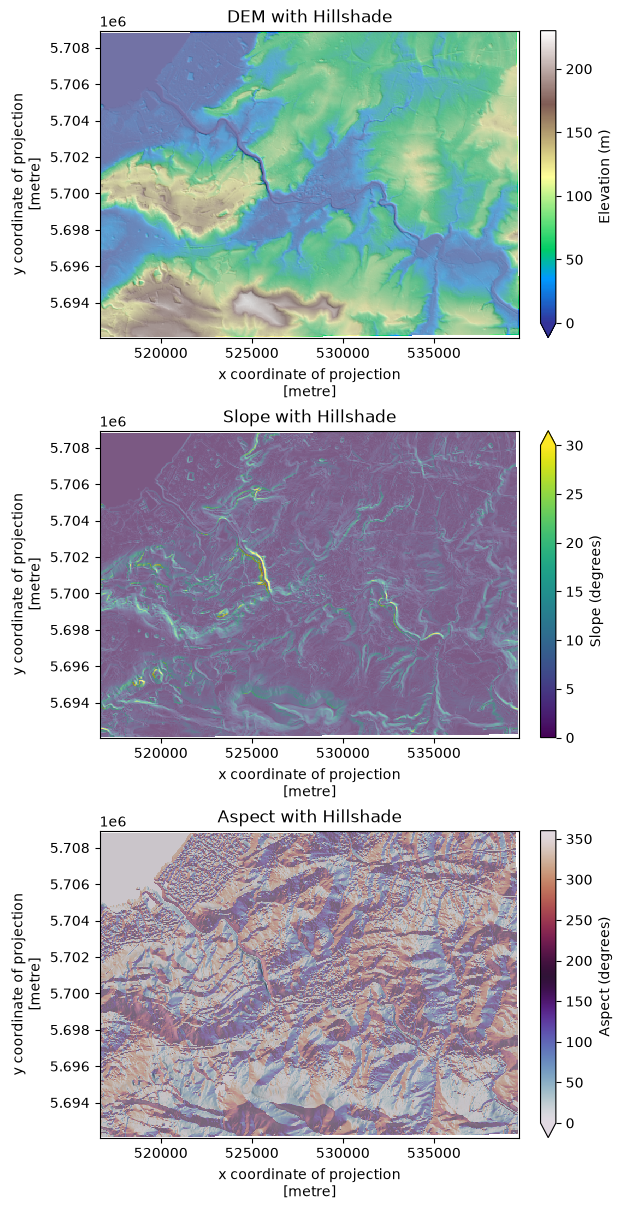

In [89]:
# plot dem, slope, and aspect in 1x3 grid, and overlay with hillshade

fig, axes = plt.subplots(nrows=3, figsize=(6, 12), layout='constrained')

ax = axes[0]
dem_reprojected.plot.imshow(ax=ax, cmap="terrain", vmin=0, vmax=230, cbar_kwargs={"label": "Elevation (m)"})
hillshade.plot.imshow(ax=ax, cmap="gray", alpha=0.5, add_colorbar=False)
ax.set_title("DEM with Hillshade")
ax.set_aspect('equal')

ax = axes[1]
slope.plot.imshow(ax=ax, cmap="viridis", vmin=0, vmax=30, cbar_kwargs={"label": "Slope (degrees)"})
hillshade.plot.imshow(ax=ax, cmap="gray", alpha=0.5, add_colorbar=False)
ax.set_title("Slope with Hillshade")
ax.set_aspect('equal')

ax = axes[2]
aspect.plot.imshow(ax=ax, cmap="twilight", vmin=0, vmax=360, cbar_kwargs={"label": "Aspect (degrees)"})
hillshade.plot.imshow(ax=ax, cmap="gray", alpha=0.5, add_colorbar=False)
ax.set_title("Aspect with Hillshade")
ax.set_aspect('equal')

plt.show()



## Multi-band rasters

We will be looking at multi-band data in greater detail next week: however, for now, we will show how it can be loaded an plotted.

Download the following multispectral image of Bristol from the Landsat 9 satellite, taking on the 11th July 2026:

 - [Bristol Landsat 9 scene 2026-07-11](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/04/bristol_2026-07-11_landsat-9.tif)

Place it in the same directory so it can be loaded in the same way as before:


In [90]:
landsat = rxr.open_rasterio("bristol_2026-07-11_landsat-9.tif")

Let's examine the dataset:

In [92]:
print("CRS of Landsat image:", landsat.rio.crs)
print("Resolution of Landsat image:", landsat.rio.resolution())
print("Bounds of Landsat image:", landsat.rio.bounds())

landsat

CRS of Landsat image: EPSG:32630
Resolution of Landsat image: (30.0, -30.0)
Bounds of Landsat image: (516645.0, 5692095.0, 539685.0, 5708925.0)


<xarray.DataArray (band: 4, y: 561, x: 768)> Size: 7MB
[1723392 values with dtype=float32]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 4kB 5.709e+06 5.709e+06 ... 5.692e+06 5.692e+06
  * x            (x) float64 6kB 5.167e+05 5.167e+05 ... 5.396e+05 5.397e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0.0
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('red', 'green', 'blue', 'nir08')

Note that the image exists autoamtically within the appropriate UTM zone, EPSG:32630.

The `DataArray` now has a `band` length of `4`, indicating that this is a multi-band image. The `band` coordinates are not very useful (`[1, 2, 3, 4]`): without good standardisation of metadata across the industry, `open_rasterio` is not always the best at detecting the band names, so they normally have to be found manually in dataset documentation or similar. Here, we can see that there is a `long_name` attribute `
('red', 'green', 'blue', 'nir08')`: this provides an indication of what our data is (specifically, red, blue, green, and near infra-red bands, in that order).

As discussed earlier, when passing a three-band image to `imshow()`, this will automatically be interpreted as an RGB image. We do this below:

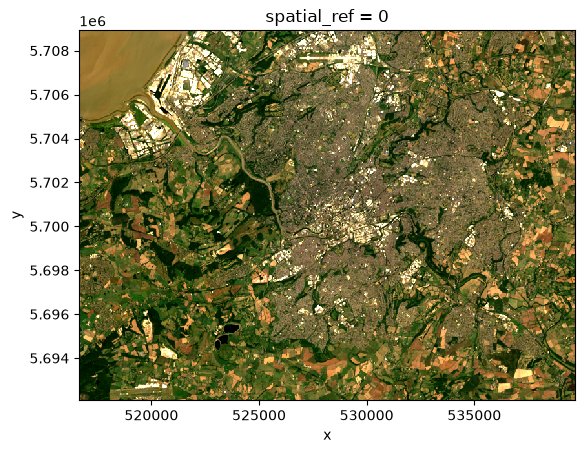

In [98]:
# Create an new dataarray with only the first three bands (Red, Green, Blue) for visualization
rgb = landsat.isel(band=[0,1,2])

rgb.plot.imshow(robust=True)  # 'robust' is a useful option to automatically scale the colorbar 
                              # based on the data distribution, which can help to visualize the image better. 
                              # Try turning this to 'False' to see what happens when the colorbar is not scaled robustly.


As this is a different dataset with a different source, even though both our DEM and Landsat image are both nominally in the same CRS (EPSG:32630) and resolution (30 m), it may be that there are subtle differences between the two datasets: they may not be properly aligned, or have different sizes and extents.

An incredibly valuable `rioxarray` function is the `.rio.reproject_match()` function. This performs all necessary functions (reprojecting, resampling, resizing, clipping) to make on image _exactly match_ another in CRS and extent.

For instance, we could make our RGB image exactly match our previous zoomed-in DEM of Bristol city centre. It wouldn't matter what the input CRS, resolution, or extent was: the output will be identical to the provided argument:

In [108]:
rgb_reproj_clipped = rgb.rio.reproject_match(dem_reproj_clip, method="bilinear")

As a result, to end this session, we can provide a neat comparison of our two raster datasets over central Bristol:

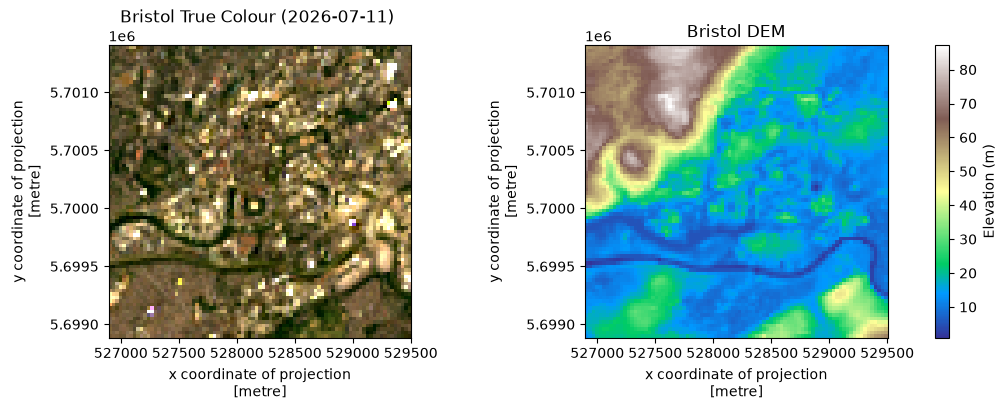

In [114]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), layout='constrained')

ax = axes[0]
rgb_reproj_clipped.plot.imshow(robust=True, ax=ax)
ax.set_title("Bristol True Colour (2026-07-11) ")
ax.set_aspect('equal')

ax = axes[1]
dem_reproj_clip.plot.imshow(cmap='terrain', cbar_kwargs={"label": "Elevation (m)"}, ax=ax)
ax.set_title("Bristol DEM")
ax.set_aspect('equal')

## Summary

We have provided an insight into `rioxarray`, and how it can be used to extend the functionality of `xarray` to deal with raster data and GeoTIFF files. We have shown how we can load, manipulate, and save raster data, and have seen how this can work with topographic (DEM) data and multispectral satellite data. Next week, we will look more into satellite data specifically: how we can begin to analyse and think about multispectral satellite data, and where we can download data.